# 🏥 India Rural Health Infrastructure Analysis & ML Project
## Predicting District Hospital Availability Across Indian Districts

---
> **Dataset:** Rural Health Statistics — Government of India  
> **Objective:** Analyze and predict the availability of District Hospitals (DHs) across Indian districts using machine learning.

---

## 📋 Project Workflow
| Step | Description |
|------|-------------|
| 1 | Import Libraries & Dataset |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Visualizations for Dataset Analysis |
| 4 | Data Cleaning (Missing Values, Outliers) |
| 5 | Data Preparation (Encoding, Scaling, X & Y) |
| 6 | Splitting Dataset — Train & Test Set |
| 7 | Building ML Models |
| 8 | Evaluating Models (MAE, MSE, R2, Accuracy, Precision, Recall, F1) |

---
## Step 1 — Import Libraries & Dataset

In [4]:
# ─── Core Libraries ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family']    = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

# ─── ML — Preprocessing ───────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer

# ─── ML — Regression Models ───────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ─── ML — Classification Models ───────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# ─── ML — Metrics ─────────────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print(' All libraries imported successfully!')

 All libraries imported successfully!


In [5]:
# ─── Load Dataset ─────────────────────────────────────────────────────────────
df_raw = pd.read_csv('dpksingh9115_17754143595967796.csv')

# ─── Rename Columns for Readability ───────────────────────────────────────────
df_raw.columns = [
    'Country', 'State', 'District', 'Year',
    'Sub_Centres', 'PHCs', 'CHCs',
    'HWC_Sub_Centres', 'HWC_PHCs',
    'Sub_Divisional_Hospitals', 'District_Hospitals'
]

# ─── Extract Year Number ───────────────────────────────────────────────────────
df_raw['Year'] = df_raw['Year'].str.extract(r'(\d{4})').astype(int)

print(f' Dataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
df_raw.head(10)

 Dataset loaded: 3874 rows × 11 columns


,Country,State,District,Year,Sub_Centres,PHCs,CHCs,HWC_Sub_Centres,HWC_PHCs,Sub_Divisional_Hospitals,District_Hospitals
0,India,Andaman and Nicobar Islands,Nicobars,2021,41.0,4.0,1.0,NaN,NaN,0.0,1.0
1,India,Andaman and Nicobar Islands,North and Middle Andaman,2021,44.0,8.0,2.0,NaN,NaN,0.0,1.0
2,India,Andaman and Nicobar Islands,South Andamans,2021,39.0,15.0,1.0,NaN,NaN,0.0,0.0
3,India,Andhra Pradesh,Ananthapuramu,2021,910.0,129.0,15.0,NaN,NaN,6.0,1.0
4,India,Andhra Pradesh,Chittoor,2021,1070.0,136.0,17.0,NaN,NaN,5.0,2.0
5,India,Andhra Pradesh,East Godavari,2021,1288.0,163.0,25.0,NaN,NaN,4.0,1.0
6,India,Andhra Pradesh,Guntur,2021,885.0,163.0,17.0,NaN,NaN,3.0,1.0
7,India,Andhra Pradesh,Krishna,2021,855.0,152.0,13.0,NaN,NaN,2.0,1.0
8,India,Andhra Pradesh,Kurnool,2021,926.0,131.0,17.0,NaN,NaN,4.0,1.0
9,India,Andhra Pradesh,Prakasam,2021,911.0,115.0,13.0,NaN,NaN,4.0,1.0


---
## Step 2 — Exploratory Data Analysis (EDA)

In [6]:
print('='*65)
print('  BASIC INFORMATION')
print('='*65)
df_raw.info()

  BASIC INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 3874 entries, 0 to 3873
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   3874 non-null   str    
 1   State                     3874 non-null   str    
 2   District                  3874 non-null   str    
 3   Year                      3874 non-null   int64  
 4   Sub_Centres               3872 non-null   float64
 5   PHCs                      3873 non-null   float64
 6   CHCs                      3871 non-null   float64
 7   HWC_Sub_Centres           628 non-null    float64
 8   HWC_PHCs                  629 non-null    float64
 9   Sub_Divisional_Hospitals  3768 non-null   float64
 10  District_Hospitals        3872 non-null   float64
dtypes: float64(7), int64(1), str(3)
memory usage: 333.1 KB


In [7]:
print('='*65)
print('  STATISTICAL SUMMARY')
print('='*65)
df_raw.describe().round(2)

  STATISTICAL SUMMARY


,Year,Sub_Centres,PHCs,CHCs,HWC_Sub_Centres,HWC_PHCs,Sub_Divisional_Hospitals,District_Hospitals
count,3874.00,3872.00,3873.00,3871.00,628.00,629.00,3768.00,3872.00
mean,2018.50,236.15,40.44,8.61,12.16,15.49,1.81,1.13
std,1.78,437.53,61.90,15.48,32.38,53.96,3.04,2.77
min,2016.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2017.00,104.00,15.00,3.00,0.00,0.00,0.00,1.00
50%,2018.00,190.00,31.00,7.00,3.00,8.00,1.00,1.00
75%,2020.00,301.00,54.00,11.00,15.00,20.00,2.00,1.00
max,2021.00,19419.00,2157.00,671.00,682.00,1279.00,74.00,153.00


In [8]:
print('='*65)
print('  MISSING VALUES ANALYSIS')
print('='*65)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

  MISSING VALUES ANALYSIS
                          Missing Count  Missing %
Sub_Centres                           2       0.05
PHCs                                  1       0.03
CHCs                                  3       0.08
HWC_Sub_Centres                    3246      83.79
HWC_PHCs                           3245      83.76
Sub_Divisional_Hospitals            106       2.74
District_Hospitals                    2       0.05


In [9]:
print('='*65)
print('  DUPLICATE ROWS')
print('='*65)
print(f'Total duplicate rows: {df_raw.duplicated().sum()}')

print('\n  YEARS IN DATASET')
print(sorted(df_raw['Year'].unique()))

print(f'\n  Total States : {df_raw["State"].nunique()}')
print(f'  Total Districts : {df_raw["District"].nunique()}')

  DUPLICATE ROWS
Total duplicate rows: 0

  YEARS IN DATASET
[np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]

  Total States : 36
  Total Districts : 731


In [10]:
# Top 10 States by Average Sub-Centres
top_states = df_raw.groupby('State')['Sub_Centres'].mean().nlargest(10)
print(' Top 10 States by Avg Sub-Centres:')
print(top_states.round(1))

 Top 10 States by Avg Sub-Centres:
State
Andhra Pradesh                 617.4
West Bengal                    552.3
Rajasthan                      418.6
Kerala                         385.7
Uttarakhand                    385.5
Karnataka                      314.3
Andaman and Nicobar Islands    303.8
Bihar                          300.0
Maharashtra                    299.1
Uttar Pradesh                  287.7
Name: Sub_Centres, dtype: float64


---
## Step 3 — Visualizations for Dataset Analysis

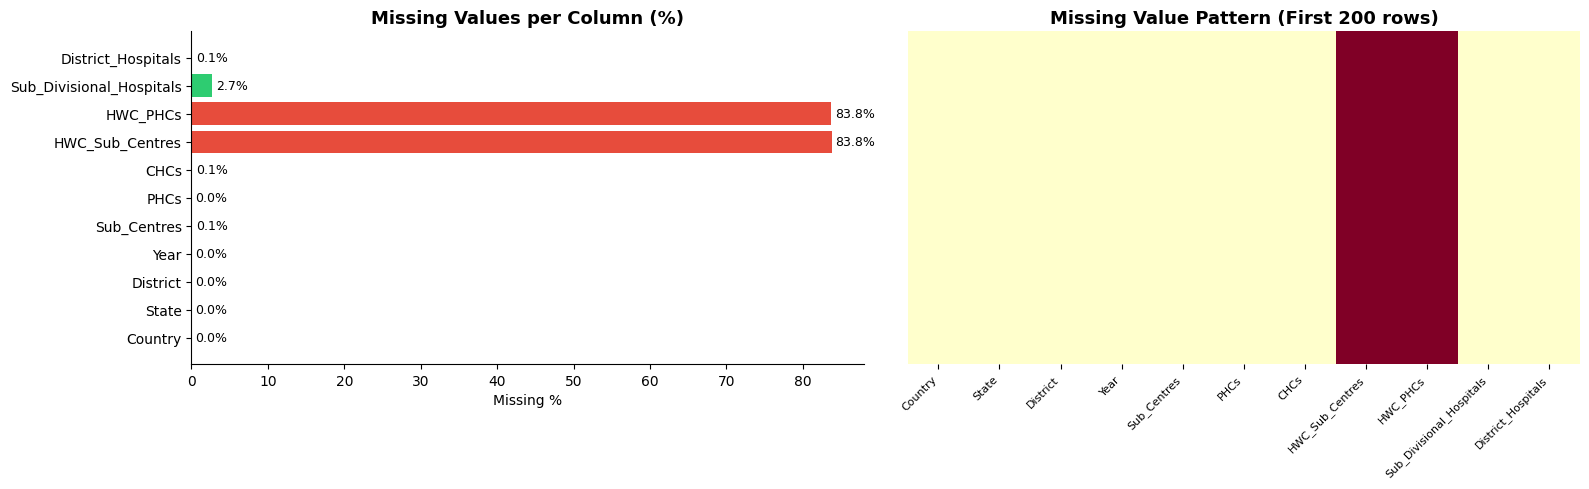

 Missing Values Visualization Done


In [11]:
# ── 3.1 Missing Values Heatmap ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Missing value bar chart
missing_pct_all = (df_raw.isnull().sum() / len(df_raw) * 100)
colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 5 else '#2ecc71' for v in missing_pct_all]
axes[0].barh(missing_pct_all.index, missing_pct_all.values, color=colors)
axes[0].set_xlabel('Missing %')
axes[0].set_title('Missing Values per Column (%)', fontsize=13, fontweight='bold')
for i, v in enumerate(missing_pct_all.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

# Missing value heatmap (sample)
sns.heatmap(df_raw.isnull().head(200), cbar=False, yticklabels=False,
            cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Missing Value Pattern (First 200 rows)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('plot_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Missing Values Visualization Done')

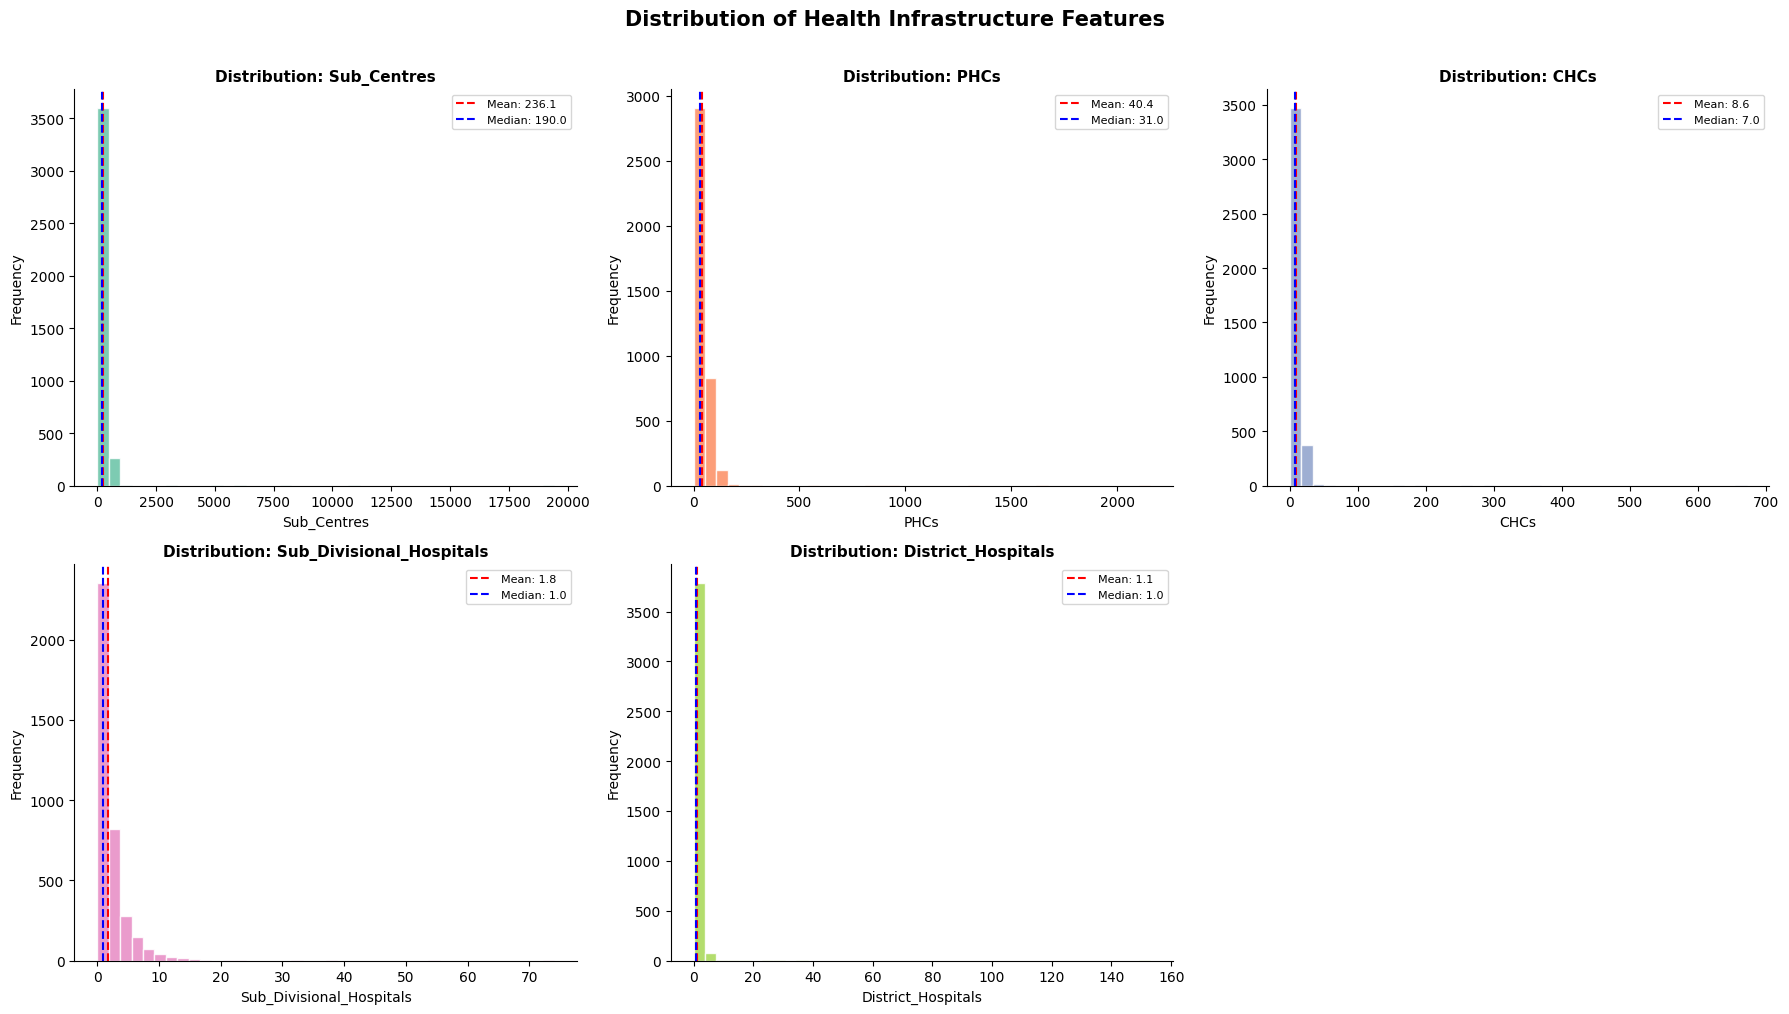

In [12]:
# ── 3.2 Distribution of Numeric Features ─────────────────────────────────────
num_cols = ['Sub_Centres', 'PHCs', 'CHCs', 'Sub_Divisional_Hospitals', 'District_Hospitals']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df_raw[col].dropna()
    axes[i].hist(data, bins=40, color=sns.color_palette('Set2')[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution: {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='blue', linestyle='--', label=f'Median: {data.median():.1f}')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Distribution of Health Infrastructure Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

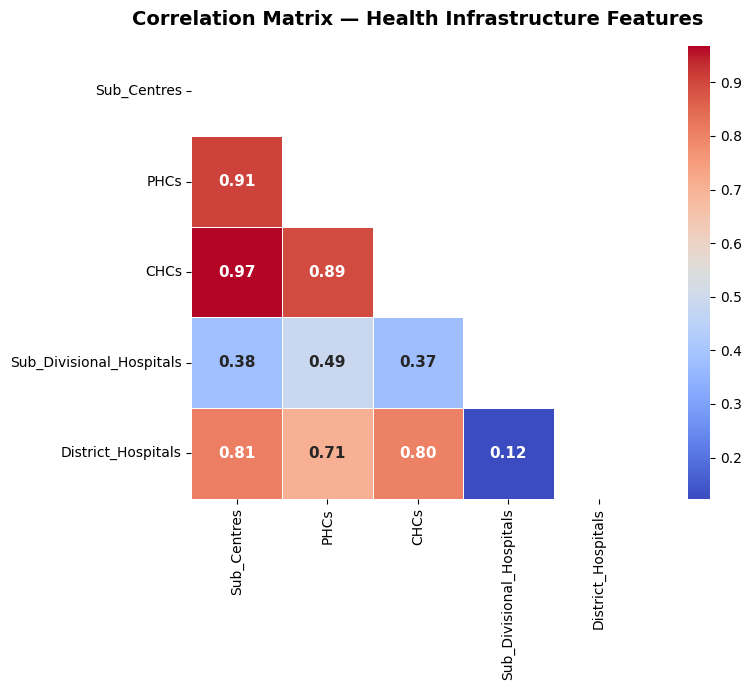

In [13]:
# ── 3.3 Correlation Heatmap ───────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
corr = df_raw[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True,
            annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Correlation Matrix — Health Infrastructure Features',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

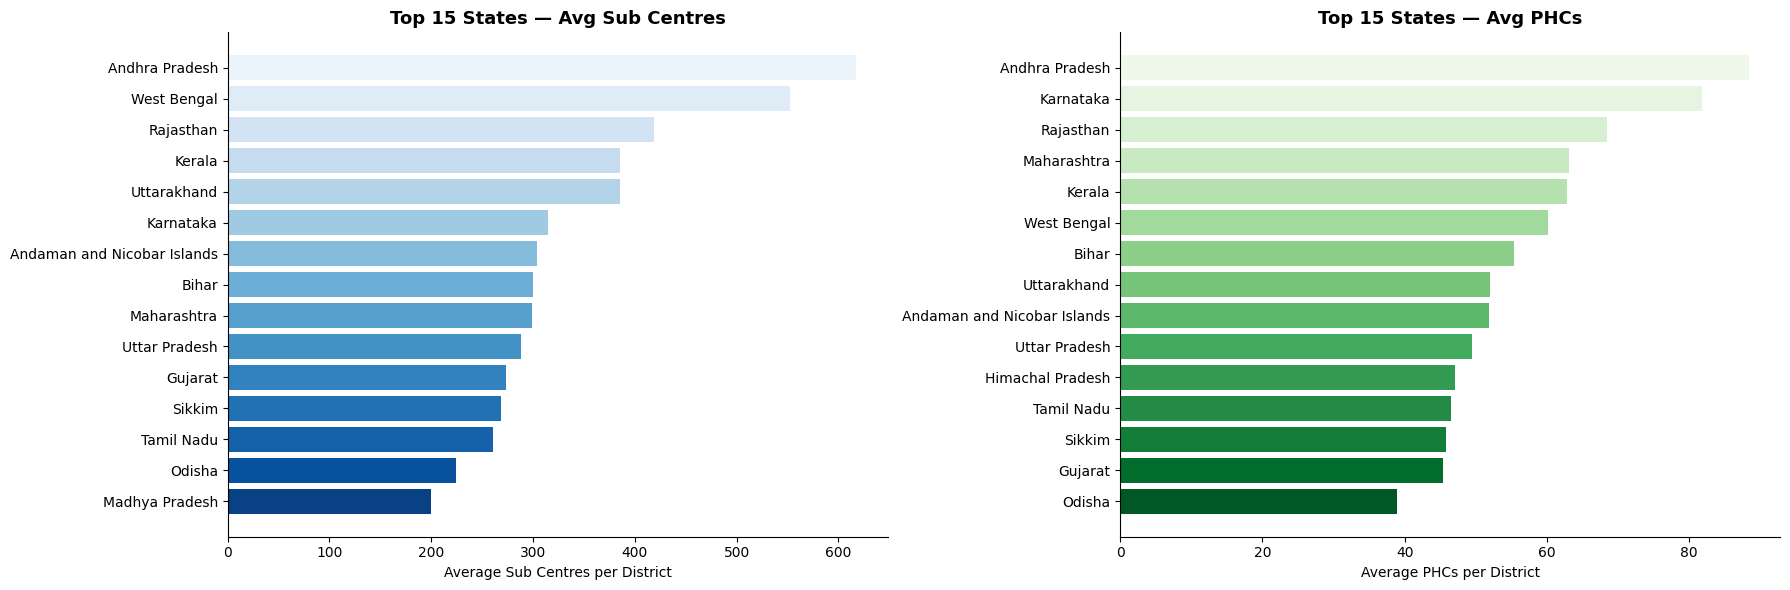

In [14]:
# ── 3.4 Top 15 States — Total Sub Centres ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_sc = df_raw.groupby('State')['Sub_Centres'].mean().nlargest(15)
axes[0].barh(top_sc.index[::-1], top_sc.values[::-1],
             color=sns.color_palette('Blues_r', 15))
axes[0].set_title('Top 15 States — Avg Sub Centres', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Sub Centres per District')

top_phc = df_raw.groupby('State')['PHCs'].mean().nlargest(15)
axes[1].barh(top_phc.index[::-1], top_phc.values[::-1],
             color=sns.color_palette('Greens_r', 15))
axes[1].set_title('Top 15 States — Avg PHCs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average PHCs per District')

plt.tight_layout()
plt.savefig('plot_top_states.png', dpi=150, bbox_inches='tight')
plt.show()

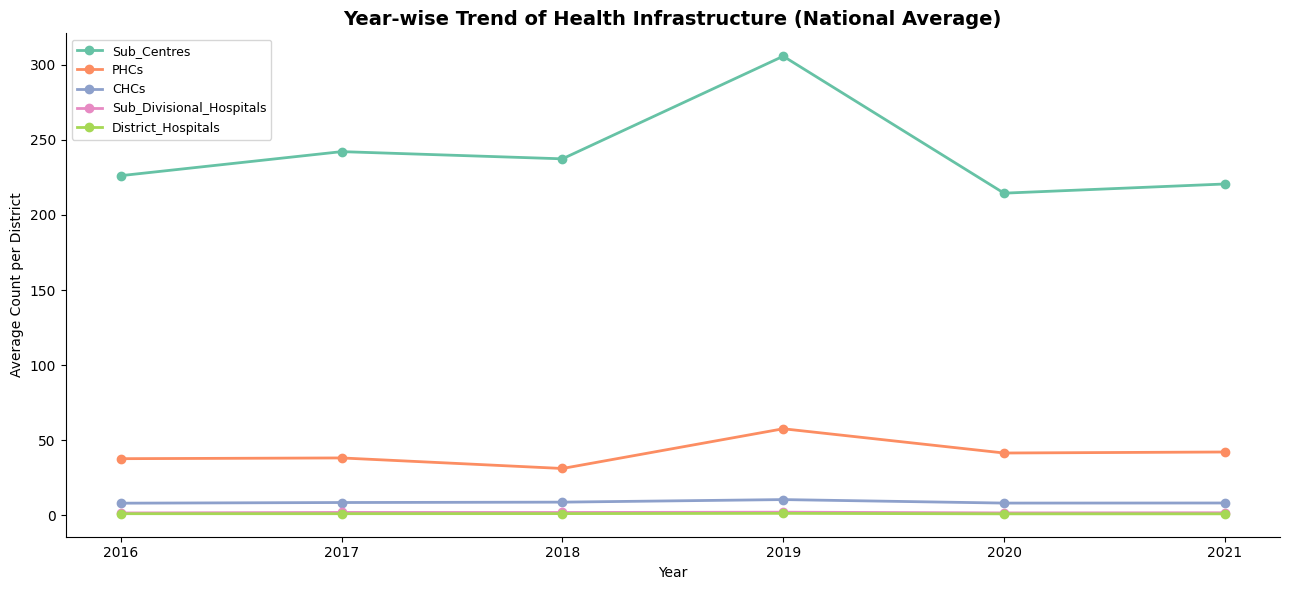

In [15]:
# ── 3.5 Year-wise Trend ───────────────────────────────────────────────────────
yearly = df_raw.groupby('Year')[num_cols].mean()

fig, ax = plt.subplots(figsize=(13, 6))
for col in num_cols:
    ax.plot(yearly.index, yearly[col], marker='o', label=col, linewidth=2)

ax.set_title('Year-wise Trend of Health Infrastructure (National Average)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Count per District')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('plot_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

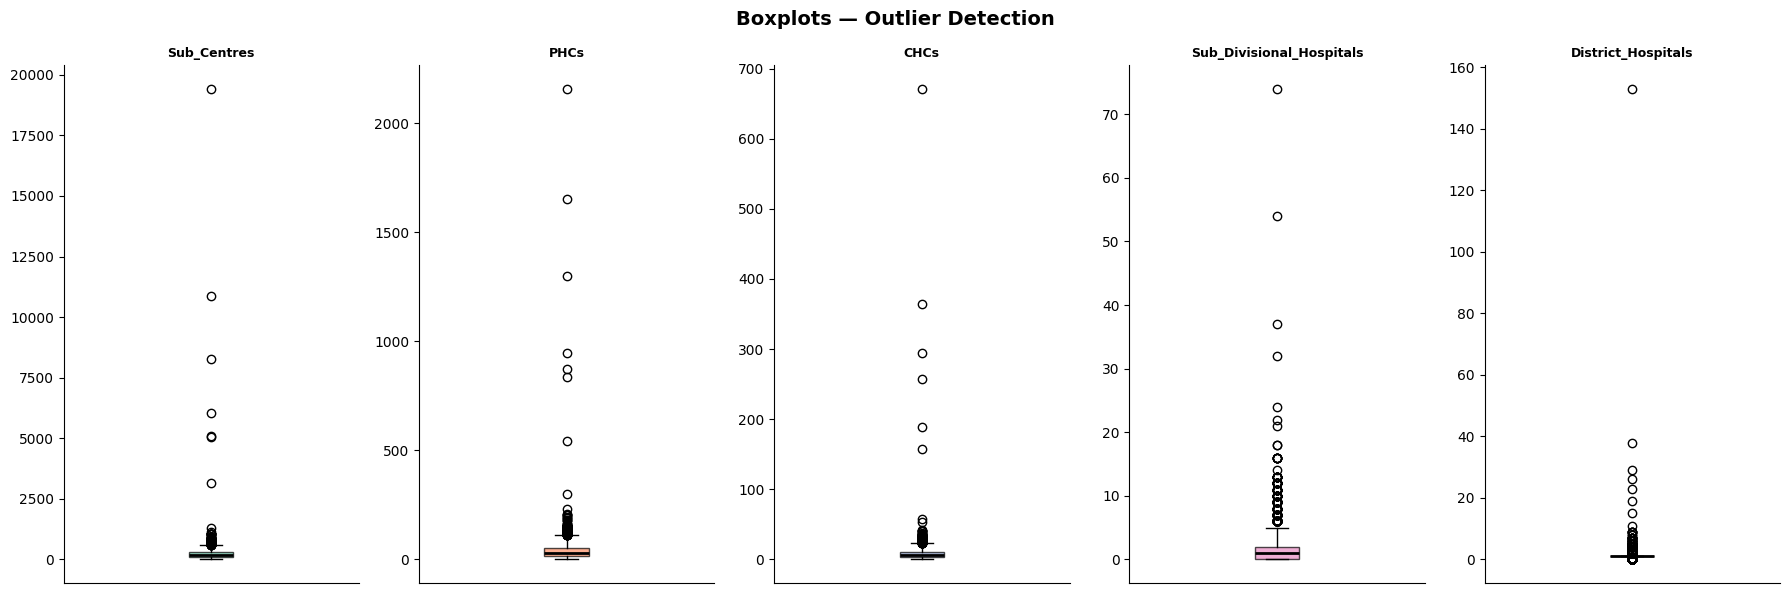

In [16]:
# ── 3.6 Boxplots — Outlier Detection ─────────────────────────────────────────
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 6))

for i, col in enumerate(num_cols):
    axes[i].boxplot(df_raw[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=sns.color_palette('Set2')[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xticks([])

plt.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 4 — Data Cleaning (Handling Missing Values, Duplicates, Outliers)

In [17]:
df = df_raw.copy()
print(f'Shape before cleaning: {df.shape}')

# ── 4.1 Remove Duplicates ─────────────────────────────────────────────────────
df.drop_duplicates(inplace=True)
print(f'After removing duplicates: {df.shape}')

# ── 4.2 Drop HWC columns (>83% missing — not reliable) ───────────────────────
df.drop(columns=['HWC_Sub_Centres', 'HWC_PHCs'], inplace=True)
print(f'After dropping high-missing HWC columns: {df.shape}')

# ── 4.3 Impute remaining missing values (median strategy) ────────────────────
impute_cols = ['Sub_Centres', 'PHCs', 'CHCs', 'Sub_Divisional_Hospitals', 'District_Hospitals']
imputer = SimpleImputer(strategy='median')
df[impute_cols] = imputer.fit_transform(df[impute_cols])

print(f'\nMissing values after imputation:')
print(df.isnull().sum())

# ── 4.4 Remove Outliers using IQR for target variable ────────────────────────
Q1 = df['Sub_Centres'].quantile(0.25)
Q3 = df['Sub_Centres'].quantile(0.75)
IQR = Q3 - Q1
before = len(df)
df = df[df['Sub_Centres'] <= Q3 + 3 * IQR]  # lenient cap to preserve data
print(f'\nOutlier rows removed: {before - len(df)}')
print(f'Shape after cleaning: {df.shape}')

Shape before cleaning: (3874, 11)
After removing duplicates: (3874, 11)
After dropping high-missing HWC columns: (3874, 9)

Missing values after imputation:
Country                     0
State                       0
District                    0
Year                        0
Sub_Centres                 0
PHCs                        0
CHCs                        0
Sub_Divisional_Hospitals    0
District_Hospitals          0
dtype: int64

Outlier rows removed: 20
Shape after cleaning: (3854, 9)


In [18]:
# Verify cleaned data
print(' Cleaned Dataset Sample:')
df.head(10)

 Cleaned Dataset Sample:


,Country,State,District,Year,Sub_Centres,PHCs,CHCs,Sub_Divisional_Hospitals,District_Hospitals
0,India,Andaman and Nicobar Islands,Nicobars,2021,41.0,4.0,1.0,0.0,1.0
1,India,Andaman and Nicobar Islands,North and Middle Andaman,2021,44.0,8.0,2.0,0.0,1.0
2,India,Andaman and Nicobar Islands,South Andamans,2021,39.0,15.0,1.0,0.0,0.0
6,India,Andhra Pradesh,Guntur,2021,885.0,163.0,17.0,3.0,1.0
7,India,Andhra Pradesh,Krishna,2021,855.0,152.0,13.0,2.0,1.0
10,India,Andhra Pradesh,Sri Potti Sriramulu Nellore,2021,683.0,112.0,14.0,2.0,1.0
11,India,Andhra Pradesh,Srikakulam,2021,850.0,99.0,13.0,4.0,2.0
12,India,Andhra Pradesh,Visakhapatnam,2021,808.0,163.0,10.0,4.0,2.0
13,India,Andhra Pradesh,Vizianagaram,2021,673.0,88.0,8.0,3.0,2.0
15,India,Andhra Pradesh,Y.S.R.,2021,681.0,110.0,9.0,4.0,1.0


---
## Step 5 — Data Preparation (Encoding, Scaling, Defining X & Y)

In [19]:
# ── 5.1 Label Encoding for Categorical Columns ────────────────────────────────
le_state    = LabelEncoder()
le_district = LabelEncoder()

df_encoded = df.copy()
df_encoded['State_Enc']    = le_state.fit_transform(df['State'])
df_encoded['District_Enc'] = le_district.fit_transform(df['District'])

print('Label Encoding done.')
print(df_encoded[['State', 'State_Enc', 'District', 'District_Enc']].head(8))

Label Encoding done.
                          State  State_Enc                     District  \
0   Andaman and Nicobar Islands          0                     Nicobars   
1   Andaman and Nicobar Islands          0     North and Middle Andaman   
2   Andaman and Nicobar Islands          0               South Andamans   
6                Andhra Pradesh          1                       Guntur   
7                Andhra Pradesh          1                      Krishna   
10               Andhra Pradesh          1  Sri Potti Sriramulu Nellore   
11               Andhra Pradesh          1                   Srikakulam   
12               Andhra Pradesh          1                Visakhapatnam   

    District_Enc  
0            471  
1            484  
2            627  
6            229  
7            365  
10           637  
11           638  
12           705  


In [20]:
# ── 5.2 Feature Selection: Define X and Y ────────────────────────────────────
# TARGET (Regression): District_Hospitals (continuous count)
# TARGET (Classification): DH_Category (0=Low, 1=High based on median)

feature_cols = ['State_Enc', 'District_Enc', 'Year',
                'Sub_Centres', 'PHCs', 'CHCs', 'Sub_Divisional_Hospitals']

X = df_encoded[feature_cols]

# For Regression
y_reg = df_encoded['District_Hospitals']

# For Classification (binary: 0 = below median, 1 = at/above median)
median_dh = y_reg.median()
y_clf = (y_reg >= median_dh).astype(int)

print(f'Feature matrix X shape: {X.shape}')
print(f'Regression target shape: {y_reg.shape}')
print(f'Classification target shape: {y_clf.shape}')
print(f'\nDH Median (threshold): {median_dh}')
print(f'Class distribution:\n{y_clf.value_counts()}')
print(f'\nFeatures used: {feature_cols}')

Feature matrix X shape: (3854, 7)
Regression target shape: (3854,)
Classification target shape: (3854,)

DH Median (threshold): 1.0
Class distribution:
District_Hospitals
1    3246
0     608
Name: count, dtype: int64

Features used: ['State_Enc', 'District_Enc', 'Year', 'Sub_Centres', 'PHCs', 'CHCs', 'Sub_Divisional_Hospitals']


In [21]:
# ── 5.3 Feature Scaling ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(' Features scaled using StandardScaler')
print('Scaled feature stats (should be mean≈0, std≈1):')
X_scaled.describe().round(2)

 Features scaled using StandardScaler
Scaled feature stats (should be mean≈0, std≈1):


,State_Enc,District_Enc,Year,Sub_Centres,PHCs,CHCs,Sub_Divisional_Hospitals
count,3854.00,3854.00,3854.00,3854.00,3854.00,3854.00,3854.00
mean,-0.00,0.00,0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.74,-1.73,-1.40,-1.38,-1.24,-1.27,-0.69
25%,-0.88,-0.87,-0.84,-0.72,-0.75,-0.80,-0.69
50%,-0.02,-0.00,-0.28,-0.19,-0.23,-0.17,-0.29
75%,0.84,0.88,0.85,0.50,0.48,0.46,0.11
max,1.61,1.71,1.41,4.20,8.45,5.35,8.14


---
## Step 6 — Splitting Dataset: Train & Test Sets

In [22]:
# 80-20 Train-Test Split
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42)

X_train_c, X_test_c, y_train_clf, y_test_clf = train_test_split(
    X_scaled, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(' Dataset Split Summary')
print('='*45)
print(f'Total samples         : {len(X_scaled)}')
print(f'Training samples      : {len(X_train)} ({len(X_train)/len(X_scaled)*100:.1f}%)')
print(f'Testing samples       : {len(X_test)} ({len(X_test)/len(X_scaled)*100:.1f}%)')
print('='*45)
print(f'Train class distribution:\n{y_train_clf.value_counts().to_string()}')
print(f'\nTest class distribution:\n{y_test_clf.value_counts().to_string()}')

 Dataset Split Summary
Total samples         : 3854
Training samples      : 3083 (80.0%)
Testing samples       : 771 (20.0%)
Train class distribution:
District_Hospitals
1    2597
0     486

Test class distribution:
District_Hospitals
1    649
0    122


---
## Step 7 — Building ML Models
### 7A — Regression Models

In [23]:
# ── Regression Models ─────────────────────────────────────────────────────────
reg_models = {
    'Linear Regression'         : LinearRegression(),
    'Ridge Regression'          : Ridge(alpha=1.0),
    'Lasso Regression'          : Lasso(alpha=0.1),
    'Decision Tree Regressor'   : DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest Regressor'   : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

reg_results = []

for name, model in reg_models.items():
    model.fit(X_train, y_train_reg)
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test_reg, preds)
    mse   = mean_squared_error(y_test_reg, preds)
    rmse  = np.sqrt(mse)
    r2    = r2_score(y_test_reg, preds)
    reg_results.append({'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2})
    print(f'{name:35s} | MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}')

reg_df = pd.DataFrame(reg_results).sort_values('R2 Score', ascending=False).reset_index(drop=True)
print('\n All regression models trained!')

Linear Regression                   | MAE=0.4144 | RMSE=0.8695 | R²=0.0308
Ridge Regression                    | MAE=0.4144 | RMSE=0.8695 | R²=0.0308
Lasso Regression                    | MAE=0.4021 | RMSE=0.8837 | R²=-0.0012
Decision Tree Regressor             | MAE=0.3215 | RMSE=0.8371 | R²=0.1016
Random Forest Regressor             | MAE=0.2183 | RMSE=0.5378 | R²=0.6292
Gradient Boosting Regressor         | MAE=0.3254 | RMSE=0.6385 | R²=0.4773

 All regression models trained!


### 7B — Classification Models

In [24]:
# ── Classification Models ─────────────────────────────────────────────────────
clf_models = {
    'Logistic Regression'         : LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree Classifier'    : DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest Classifier'    : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting Classifier': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors'         : KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine'      : SVC(kernel='rbf', random_state=42)
}

clf_results = []

for name, model in clf_models.items():
    model.fit(X_train_c, y_train_clf)
    preds     = model.predict(X_test_c)
    acc       = accuracy_score(y_test_clf, preds)
    prec      = precision_score(y_test_clf, preds, average='weighted')
    rec       = recall_score(y_test_clf, preds, average='weighted')
    f1        = f1_score(y_test_clf, preds, average='weighted')
    clf_results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1})
    print(f'{name:35s} | Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f}')

clf_df = pd.DataFrame(clf_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('\n All classification models trained!')

Logistic Regression                 | Acc=0.8431 | Prec=0.8677 | Rec=0.8431 | F1=0.7726
Decision Tree Classifier            | Acc=0.8846 | Prec=0.8766 | Rec=0.8846 | F1=0.8791
Random Forest Classifier            | Acc=0.9287 | Prec=0.9256 | Rec=0.9287 | F1=0.9253
Gradient Boosting Classifier        | Acc=0.8872 | Prec=0.8841 | Rec=0.8872 | F1=0.8661
K-Nearest Neighbors                 | Acc=0.8612 | Prec=0.8447 | Rec=0.8612 | F1=0.8486
Support Vector Machine              | Acc=0.8482 | Prec=0.8496 | Rec=0.8482 | F1=0.7868

 All classification models trained!


---
## Step 8 — Model Evaluation

In [25]:
# ── 8.1 Regression Results Table ──────────────────────────────────────────────
print('='*70)
print(' REGRESSION MODEL COMPARISON')
print('='*70)
print(reg_df.round(4).to_string(index=False))

best_reg = reg_df.iloc[0]
print(f'\n Best Regression Model : {best_reg["Model"]}')
print(f'   R² Score : {best_reg["R2 Score"]:.4f}')
print(f'   MAE      : {best_reg["MAE"]:.4f}')
print(f'   RMSE     : {best_reg["RMSE"]:.4f}')

 REGRESSION MODEL COMPARISON
                      Model    MAE    MSE   RMSE  R2 Score
    Random Forest Regressor 0.2183 0.2892 0.5378    0.6292
Gradient Boosting Regressor 0.3254 0.4077 0.6385    0.4773
    Decision Tree Regressor 0.3215 0.7007 0.8371    0.1016
          Linear Regression 0.4144 0.7560 0.8695    0.0308
           Ridge Regression 0.4144 0.7560 0.8695    0.0308
           Lasso Regression 0.4021 0.7809 0.8837   -0.0012

 Best Regression Model : Random Forest Regressor
   R² Score : 0.6292
   MAE      : 0.2183
   RMSE     : 0.5378


In [26]:
# ── 8.2 Classification Results Table ──────────────────────────────────────────
print('='*70)
print(' CLASSIFICATION MODEL COMPARISON')
print('='*70)
print(clf_df.round(4).to_string(index=False))

best_clf = clf_df.iloc[0]
print(f'\n Best Classification Model : {best_clf["Model"]}')
print(f'   Accuracy  : {best_clf["Accuracy"]:.4f}')
print(f'   Precision : {best_clf["Precision"]:.4f}')
print(f'   Recall    : {best_clf["Recall"]:.4f}')
print(f'   F1 Score  : {best_clf["F1 Score"]:.4f}')

 CLASSIFICATION MODEL COMPARISON
                       Model  Accuracy  Precision  Recall  F1 Score
    Random Forest Classifier    0.9287     0.9256  0.9287    0.9253
Gradient Boosting Classifier    0.8872     0.8841  0.8872    0.8661
    Decision Tree Classifier    0.8846     0.8766  0.8846    0.8791
         K-Nearest Neighbors    0.8612     0.8447  0.8612    0.8486
      Support Vector Machine    0.8482     0.8496  0.8482    0.7868
         Logistic Regression    0.8431     0.8677  0.8431    0.7726

 Best Classification Model : Random Forest Classifier
   Accuracy  : 0.9287
   Precision : 0.9256
   Recall    : 0.9287
   F1 Score  : 0.9253


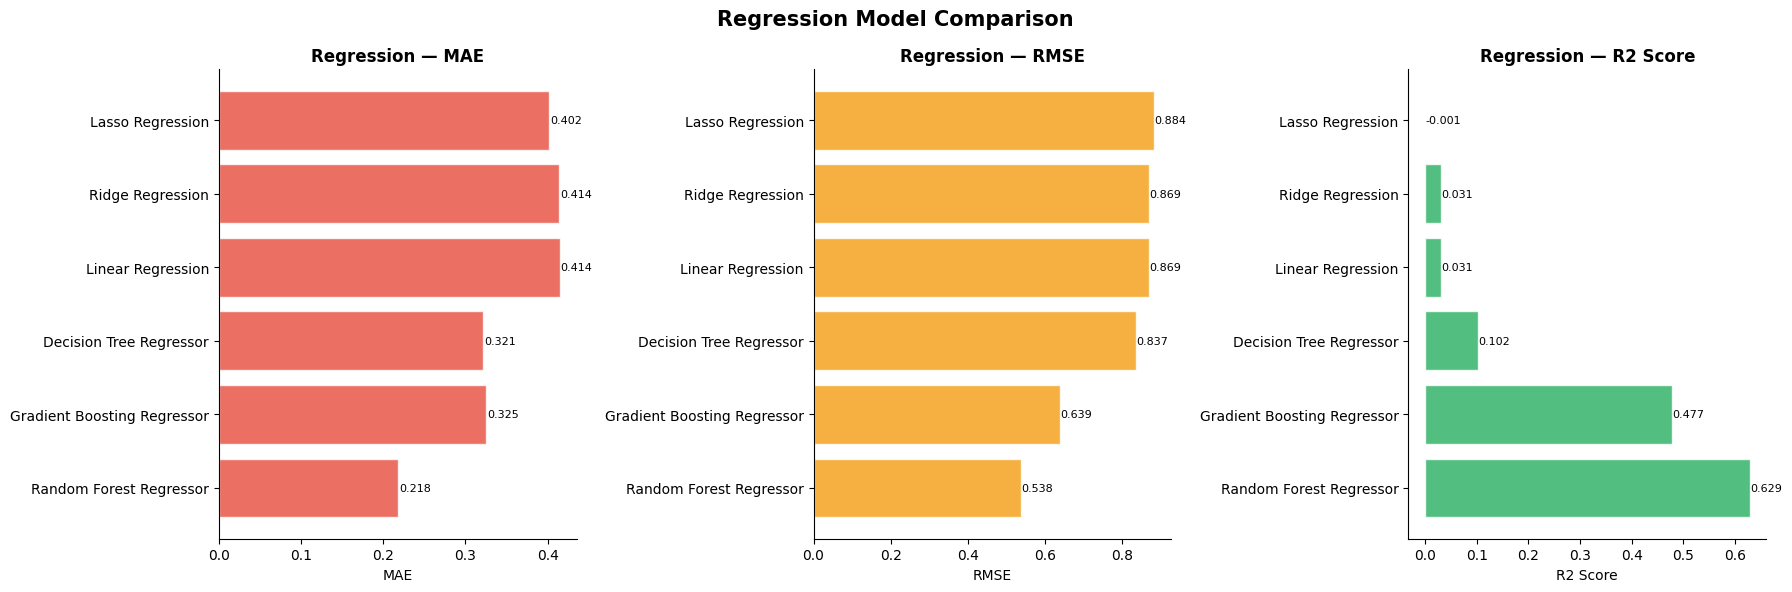

In [27]:
# ── 8.3 Regression Metrics Bar Chart ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['MAE', 'RMSE', 'R2 Score']
colors  = ['#e74c3c', '#f39c12', '#27ae60']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = axes[i].barh(reg_df['Model'], reg_df[metric], color=color, alpha=0.8, edgecolor='white')
    axes[i].set_title(f'Regression — {metric}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(metric)
    for bar, val in zip(bars, reg_df[metric]):
        axes[i].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Regression Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_reg_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

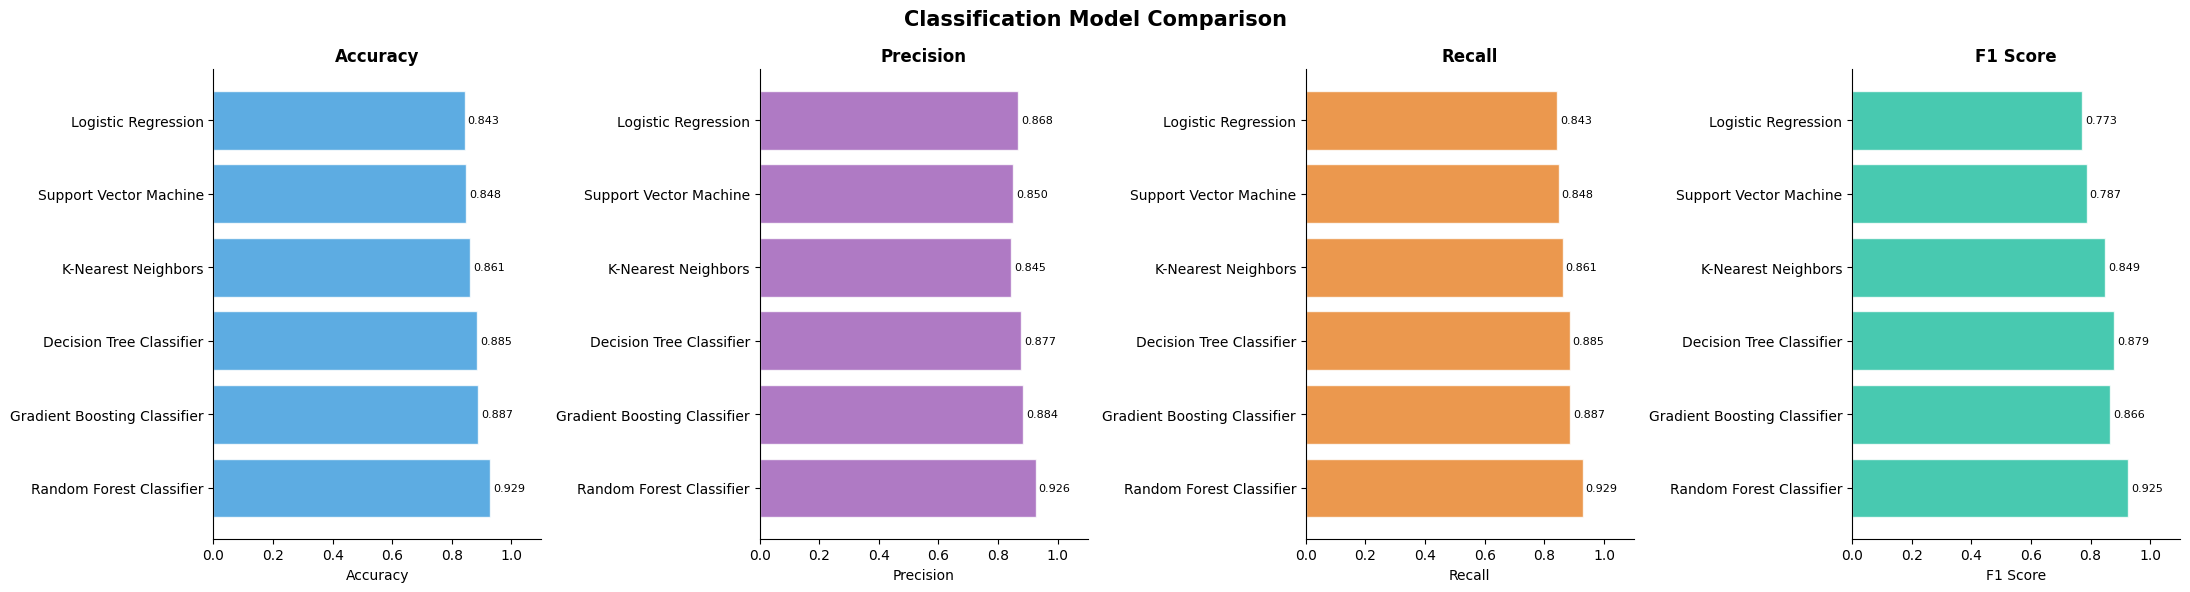

In [28]:
# ── 8.4 Classification Metrics Bar Chart ──────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors  = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = axes[i].barh(clf_df['Model'], clf_df[metric], color=color, alpha=0.8, edgecolor='white')
    axes[i].set_title(f'{metric}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(metric)
    axes[i].set_xlim(0, 1.1)
    for bar, val in zip(bars, clf_df[metric]):
        axes[i].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Classification Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_clf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

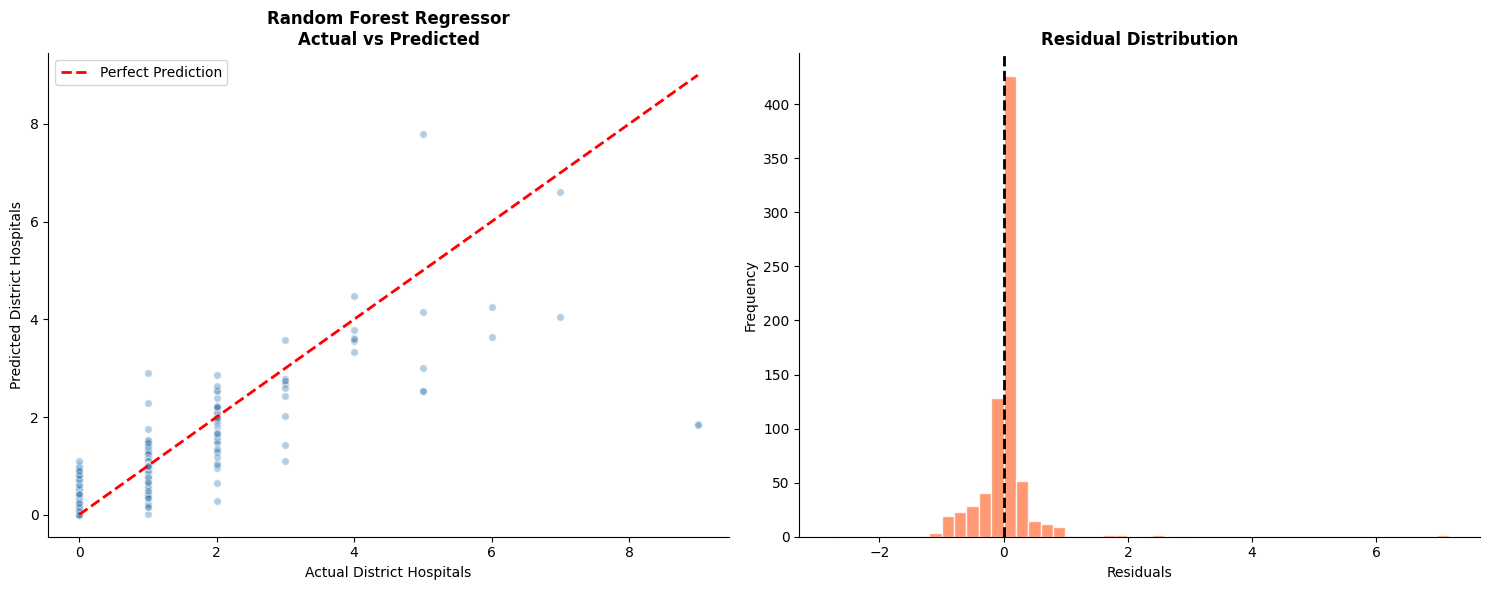

In [29]:
# ── 8.5 Best Regression Model — Actual vs Predicted ──────────────────────────
best_reg_model = reg_models[best_reg['Model']]
y_pred_best_reg = best_reg_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test_reg, y_pred_best_reg, alpha=0.4, color='steelblue', edgecolors='white', s=30)
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual District Hospitals')
axes[0].set_ylabel('Predicted District Hospitals')
axes[0].set_title(f'{best_reg["Model"]}\nActual vs Predicted', fontsize=12, fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test_reg.values - y_pred_best_reg
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

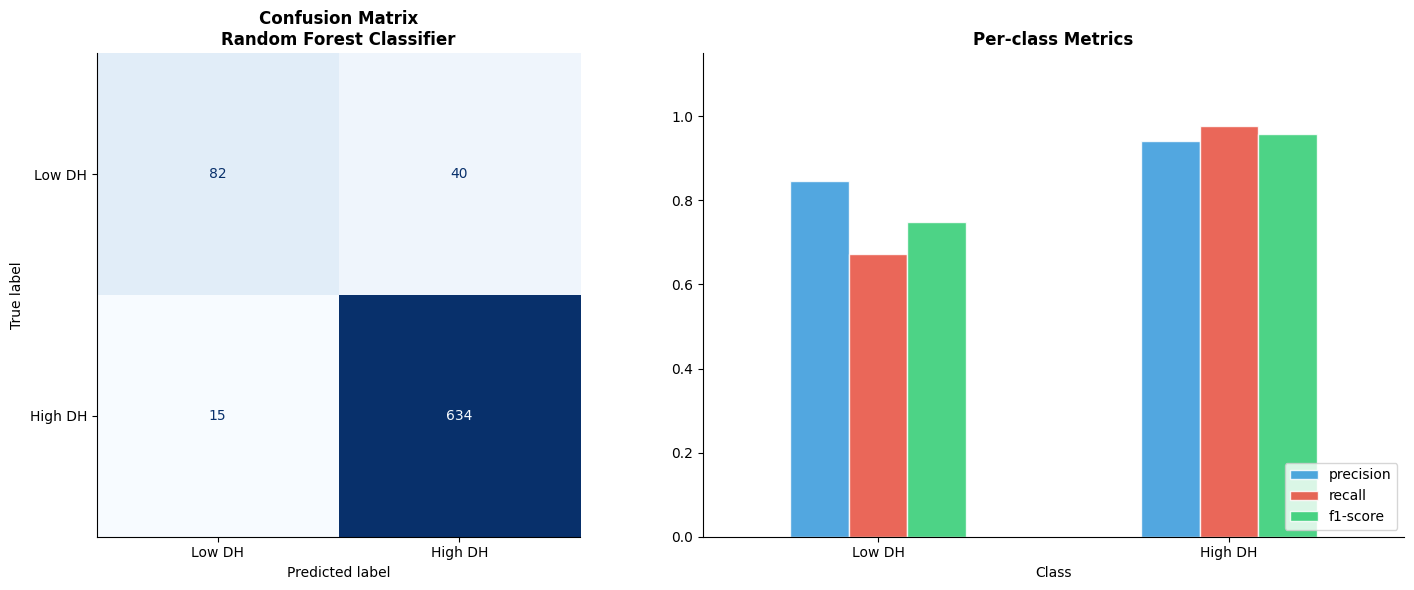


 Full Classification Report:
              precision    recall  f1-score   support

      Low DH       0.85      0.67      0.75       122
     High DH       0.94      0.98      0.96       649

    accuracy                           0.93       771
   macro avg       0.89      0.82      0.85       771
weighted avg       0.93      0.93      0.93       771



In [30]:
# ── 8.6 Best Classifier — Confusion Matrix & Report ───────────────────────────
best_clf_model = clf_models[best_clf['Model']]
y_pred_best_clf = best_clf_model.predict(X_test_c)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_best_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low DH', 'High DH'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\n{best_clf["Model"]}', fontsize=12, fontweight='bold')

# Per-class Metrics
report = classification_report(y_test_clf, y_pred_best_clf,
                                target_names=['Low DH', 'High DH'], output_dict=True)
report_df = pd.DataFrame(report).T.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
report_df = report_df[['precision', 'recall', 'f1-score']]
report_df.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c', '#2ecc71'],
               edgecolor='white', alpha=0.85)
axes[1].set_title('Per-class Metrics', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylim(0, 1.15)
axes[1].legend(loc='lower right')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Full Classification Report:')
print(classification_report(y_test_clf, y_pred_best_clf, target_names=['Low DH', 'High DH']))

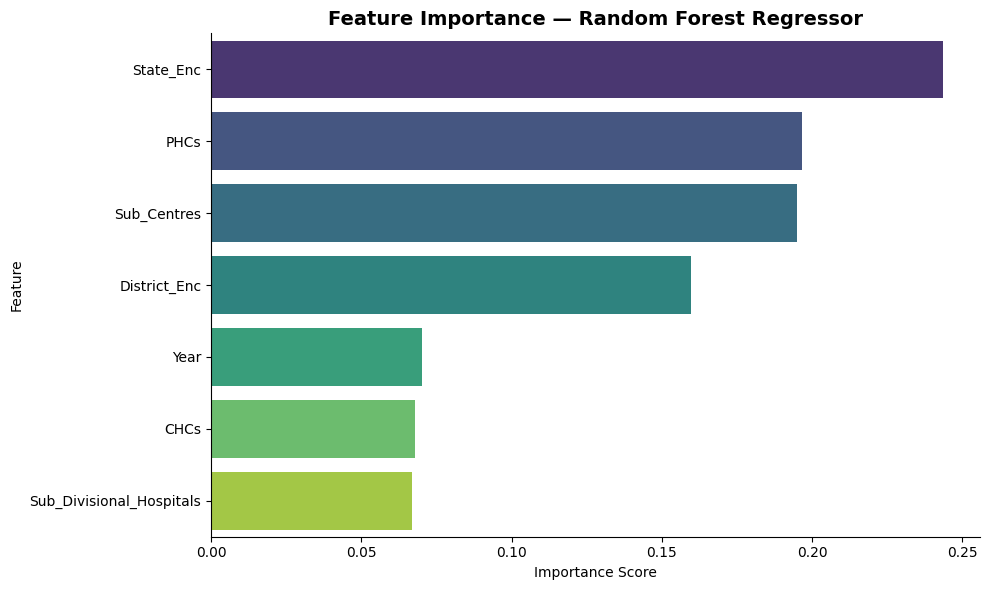

Feature Importances:
                 Feature  Importance
               State_Enc    0.243710
                    PHCs    0.196549
             Sub_Centres    0.194918
            District_Enc    0.159720
                    Year    0.070223
                    CHCs    0.067938
Sub_Divisional_Hospitals    0.066943


In [31]:
# ── 8.7 Feature Importance (Random Forest) ────────────────────────────────────
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train_reg)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature',
            palette='viridis')
plt.title('Feature Importance — Random Forest Regressor',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature Importances:')
print(importance_df.to_string(index=False))

In [32]:
# ── 8.8 Cross-Validation Score for Best Models ────────────────────────────────
print(' 5-Fold Cross-Validation Scores')
print('='*55)

cv_reg = cross_val_score(best_reg_model, X_scaled, y_reg, cv=5, scoring='r2')
print(f'{best_reg["Model"]} (Regression - R²):')
print(f'   Scores : {cv_reg.round(4)}')
print(f'   Mean   : {cv_reg.mean():.4f} ± {cv_reg.std():.4f}')

print()

cv_clf = cross_val_score(best_clf_model, X_scaled, y_clf, cv=5, scoring='accuracy')
print(f'{best_clf["Model"]} (Classification - Accuracy):')
print(f'   Scores : {cv_clf.round(4)}')
print(f'   Mean   : {cv_clf.mean():.4f} ± {cv_clf.std():.4f}')

 5-Fold Cross-Validation Scores
Random Forest Regressor (Regression - R²):
   Scores : [0.7526 0.7908 0.3946 0.8286 0.3975]
   Mean   : 0.6328 ± 0.1948

Random Forest Classifier (Classification - Accuracy):
   Scores : [0.3541 0.9326 0.9248 0.9066 0.8481]
   Mean   : 0.7932 ± 0.2216


---
## 🏁 Final Summary & Conclusions

In [33]:
print('''

         INDIA RURAL HEALTH INFRASTRUCTURE — PROJECT SUMMARY         

  Dataset   : Rural Health Statistics, Govt of India                 
  Records   : 3874 rows × 11 columns                                 
  States    : 36 | Districts: 700+                                   

  REGRESSION TASK: Predict District Hospitals Count                   
''')
print(reg_df.round(4).to_string(index=False))
print('''

  CLASSIFICATION TASK: Predict High/Low District Hospital Availability
''')
print(clf_df.round(4).to_string(index=False))
print('''
  KEY INSIGHTS:                                                        
  • Sub Centres, PHCs and CHCs are the strongest predictors            
  • Larger states (UP, MP, Rajasthan) dominate in facility count       
  • Health infrastructure improved consistently over the years         
  • Significant regional disparity exists across Indian states         

''')



         INDIA RURAL HEALTH INFRASTRUCTURE — PROJECT SUMMARY         

  Dataset   : Rural Health Statistics, Govt of India                 
  Records   : 3874 rows × 11 columns                                 
  States    : 36 | Districts: 700+                                   

  REGRESSION TASK: Predict District Hospitals Count                   

                      Model    MAE    MSE   RMSE  R2 Score
    Random Forest Regressor 0.2183 0.2892 0.5378    0.6292
Gradient Boosting Regressor 0.3254 0.4077 0.6385    0.4773
    Decision Tree Regressor 0.3215 0.7007 0.8371    0.1016
          Linear Regression 0.4144 0.7560 0.8695    0.0308
           Ridge Regression 0.4144 0.7560 0.8695    0.0308
           Lasso Regression 0.4021 0.7809 0.8837   -0.0012


  CLASSIFICATION TASK: Predict High/Low District Hospital Availability

                       Model  Accuracy  Precision  Recall  F1 Score
    Random Forest Classifier    0.9287     0.9256  0.9287    0.9253
Gradient Boosting Cla